In [1]:
# ============================================================
# Imports
# ============================================================

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.feature_engineering import prepare_features, split_train_test_by_time

pd.set_option('display.max_columns', None)

print("✓ Imports successful")

✓ Imports successful


In [ ]:
# ============================================================
# Loading Data and Configuration
# ============================================================

# Loading Configuration
with open('../config/model_config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Loading Data
df = pd.read_csv('../data/processed/dataset.csv')
df['start_time'] = pd.to_datetime(df['start_time'])

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

print(f"\n Dataset: {df.shape}")
print(f"\n Target: {config['target']}")
print(f"\n Features:")
print(f"  Categorical: {config['features']['categorical']}")
print(f"  Numerical: {config['features']['numerical']}")

FEATURE ENGINEERING

 Dataset: (79876, 20)

 Target: is_result

 Features:
  Categorical: ['region', 'age_group', 'debt_amount_bucket', 'product_type', 'preferred_language', 'segment', 'treename']
  Numerical: ['risk_score', 'hour', 'is_weekend', 'client_call_number', 'client_prev_result_rate', 'client_prev_contact_rate', 'days_since_last_call']


In [4]:
# ============================================================
# Train/Test Split by Time
# ============================================================

train_df, test_df = split_train_test_by_time(df, config)

print(f"\n✓ Train set: {len(train_df):,} samples")
print(f"✓ Test set: {len(test_df):,} samples")


TRAIN/TEST SPLIT

📊 Split by time (test starts: 2025-02-15):
  Train: 66,030 samples (2024-10-01 to 2025-02-14)
  Test:  13,846 samples (2025-02-15 to 2025-03-15)

  Train target distribution:
    Positive: 5,931.0 (8.98%)
  Test target distribution:
    Positive: 1,196.0 (8.64%)

✓ Train set: 66,030 samples
✓ Test set: 13,846 samples


In [5]:
# ============================================================
# Preparing Features
# ============================================================

# Training encoders on train data
X_train, y_train, encoders = prepare_features(train_df, config, fit_encoders=True)

# Applying encoders to test data
X_test, y_test, _ = prepare_features(test_df, config, fit_encoders=False, encoders=encoders)

print(f"\n✓ Train features: {X_train.shape}")
print(f"✓ Test features: {X_test.shape}")


FEATURE ENGINEERING

📋 Features:
  Categorical: 7
  Numerical: 7

✓ Feature matrix shape: (66030, 14)
  Samples: 66,030
  Features: 14

FEATURE ENGINEERING

📋 Features:
  Categorical: 7
  Numerical: 7

✓ Feature matrix shape: (13846, 14)
  Samples: 13,846
  Features: 14

✓ Train features: (66030, 14)
✓ Test features: (13846, 14)


In [6]:
# ============================================================
# Checking Encoders
# ============================================================

print("=" * 60)
print("CATEGORICAL ENCODERS")
print("=" * 60)

for feature, encoder in encoders.items():
    print(f"\n{feature}:")
    print(f"  Classes: {list(encoder.classes_)}")

CATEGORICAL ENCODERS

region:
  Classes: ['Aktobe', 'Almaty', 'Astana', 'Karaganda', 'Shymkent']

age_group:
  Classes: ['18-25', '26-35', '36-50', '50+']

debt_amount_bucket:
  Classes: ['10k-50k', '50k-100k', '<10k', '>100k']

product_type:
  Classes: ['Cash Loan', 'Credit Card', 'Installment']

preferred_language:
  Classes: ['kk', 'ru']

segment:
  Classes: ['1-2 RB', '3-6 НБ', 'Обещания']

treename:
  Classes: ['SoftCollection1and2RZKZVerifNew', 'SoftCollection3and6NBKZBertClass2', 'SoftCollectionPromisesKZBertClass']


FEATURE DISTRIBUTIONS (AFTER ENGINEERING)


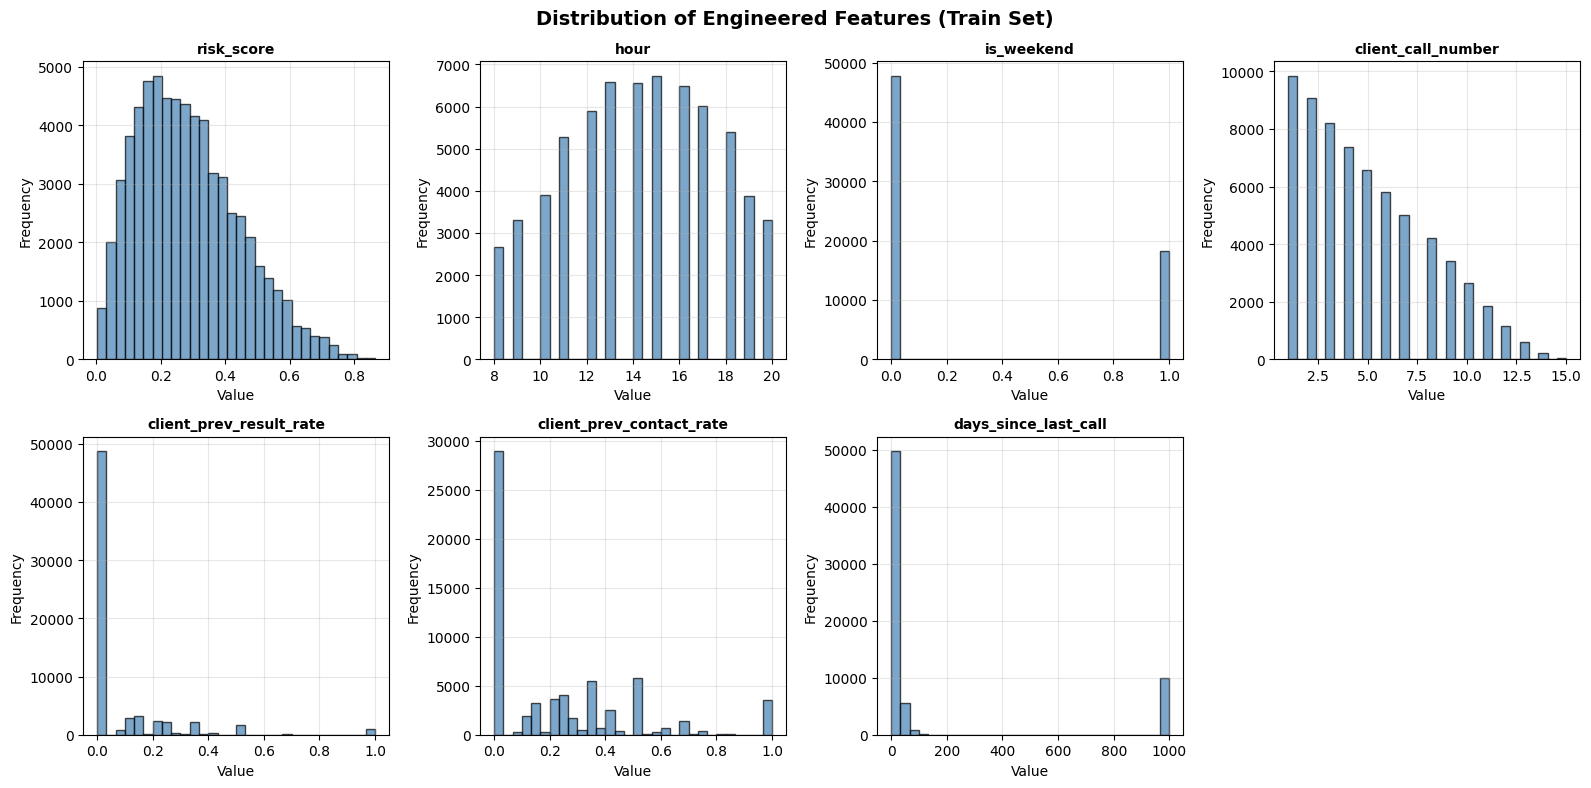

In [7]:
# ============================================================
# Feature Distributions (AFTER ENGINEERING)
# ============================================================

print("=" * 60)
print("FEATURE DISTRIBUTIONS (AFTER ENGINEERING)")
print("=" * 60)

# Numerical features are the first 7 columns after encoding
numerical_cols = X_train.columns[:7].tolist()  # Первые 7 — числовые

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].hist(X_train[feature], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{feature}', fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)

# Hide any unused subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribution of Engineered Features (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Checking for Missing Values and Outliers
# ============================================================

print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# Missing values
print("\n Missing values in Train:")
missing_train = X_train.isnull().sum()
if missing_train.sum() > 0:
    print(missing_train[missing_train > 0])
else:
    print("  ✓ No missing values")

# Outliers (simple check via percentiles)
print("\n Feature ranges (Train):")
print(X_train.describe().T[['min', '25%', '50%', '75%', 'max']])

DATA QUALITY CHECK

 Missing values in Train:
  ✓ No missing values

 Feature ranges (Train):
                               min        25%        50%        75%        max
risk_score                0.002798   0.161814   0.263403   0.386183    0.86494
hour                      8.000000  12.000000  14.000000  17.000000   20.00000
is_weekend                0.000000   0.000000   0.000000   1.000000    1.00000
client_call_number        1.000000   2.000000   4.000000   7.000000   15.00000
client_prev_result_rate   0.000000   0.000000   0.000000   0.100000    1.00000
client_prev_contact_rate  0.000000   0.000000   0.166667   0.333333    1.00000
days_since_last_call      0.000093   5.150179  13.245081  32.979902  999.00000
region                    0.000000   1.000000   2.000000   3.000000    4.00000
age_group                 0.000000   1.000000   1.000000   2.000000    3.00000
debt_amount_bucket        0.000000   0.000000   1.000000   2.000000    3.00000
product_type              0.000000   

CLASS BALANCE


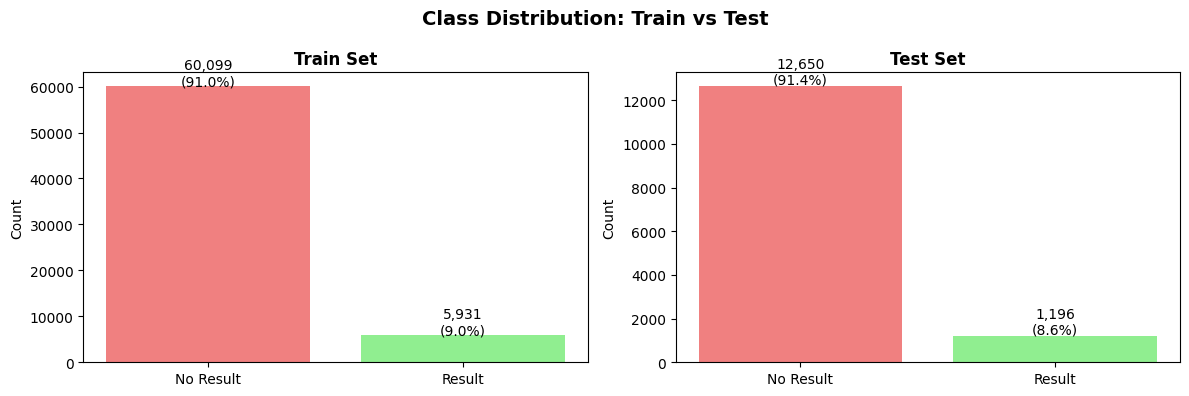

In [9]:
# ============================================================
# Class Balance
# ============================================================

print("=" * 60)
print("CLASS BALANCE")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
train_counts = y_train.value_counts()
axes[0].bar(['No Result', 'Result'], train_counts.values, color=['lightcoral', 'lightgreen'])
axes[0].set_title('Train Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(y_train):.1%})', ha='center')

# Test
test_counts = y_test.value_counts()
axes[1].bar(['No Result', 'Result'], test_counts.values, color=['lightcoral', 'lightgreen'])
axes[1].set_title('Test Set', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 100, f'{v:,}\n({v/len(y_test):.1%})', ha='center')

plt.suptitle('Class Distribution: Train vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Saving Processed Data
# ============================================================

# Saving for use in modeling notebook
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False, header=True)
y_test.to_csv('../data/processed/y_test.csv', index=False, header=True)

print("=" * 60)
print("✓✓✓ FEATURE ENGINEERING COMPLETE ✓✓✓")
print("=" * 60)

print("\n💾 Saved processed data:")
print("  X_train.csv, X_test.csv")
print("  y_train.csv, y_test.csv")

✓✓✓ FEATURE ENGINEERING COMPLETE ✓✓✓

💾 Saved processed data:
  X_train.csv, X_test.csv
  y_train.csv, y_test.csv
